# Final Evaluation
Comprehensive evaluation of the XGBoost model with business impact analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve, fbeta_score
)
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Load data and model
X_train = pd.read_parquet('../data/X_train.parquet').drop(columns=['installment','total_acc'])
X_test  = pd.read_parquet('../data/X_test.parquet').drop(columns=['installment','total_acc'])
y_train = pd.read_parquet('../data/y_train.parquet').squeeze()
y_test  = pd.read_parquet('../data/y_test.parquet').squeeze()

with open('../data/xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../data/threshold.txt') as f:
    THRESHOLD = float(f.read())

proba = model.predict_proba(X_test)[:, 1]
preds = (proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()

print('Model loaded. Threshold:', THRESHOLD)
print('Test set size:', len(y_test))

Model loaded. Threshold: 0.35
Test set size: 269612


## 1. Confusion Matrix

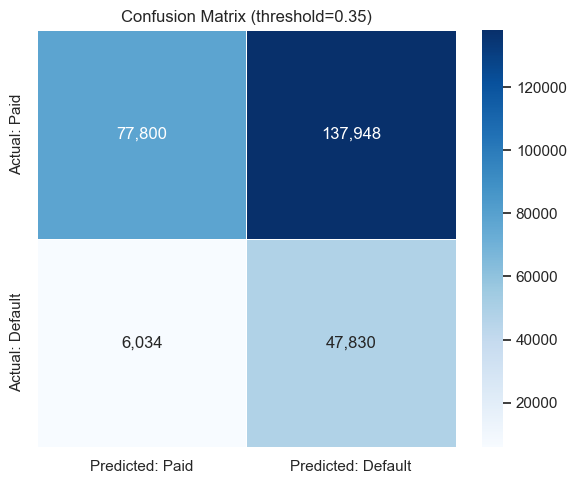

              precision    recall  f1-score   support

  Fully Paid       0.93      0.36      0.52    215748
     Default       0.26      0.89      0.40     53864

    accuracy                           0.47    269612
   macro avg       0.59      0.62      0.46    269612
weighted avg       0.79      0.47      0.50    269612



In [2]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_df = pd.DataFrame(
    cm,
    index=['Actual: Paid', 'Actual: Default'],
    columns=['Predicted: Paid', 'Predicted: Default']
)
sns.heatmap(cm_df, annot=True, fmt=',', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title(f'Confusion Matrix (threshold={THRESHOLD})')
plt.tight_layout()
plt.savefig('../data/eval_confusion_matrix.png', dpi=100)
plt.show()

print(classification_report(y_test, preds, target_names=['Fully Paid', 'Default']))

## 2. ROC & Precision-Recall Curves

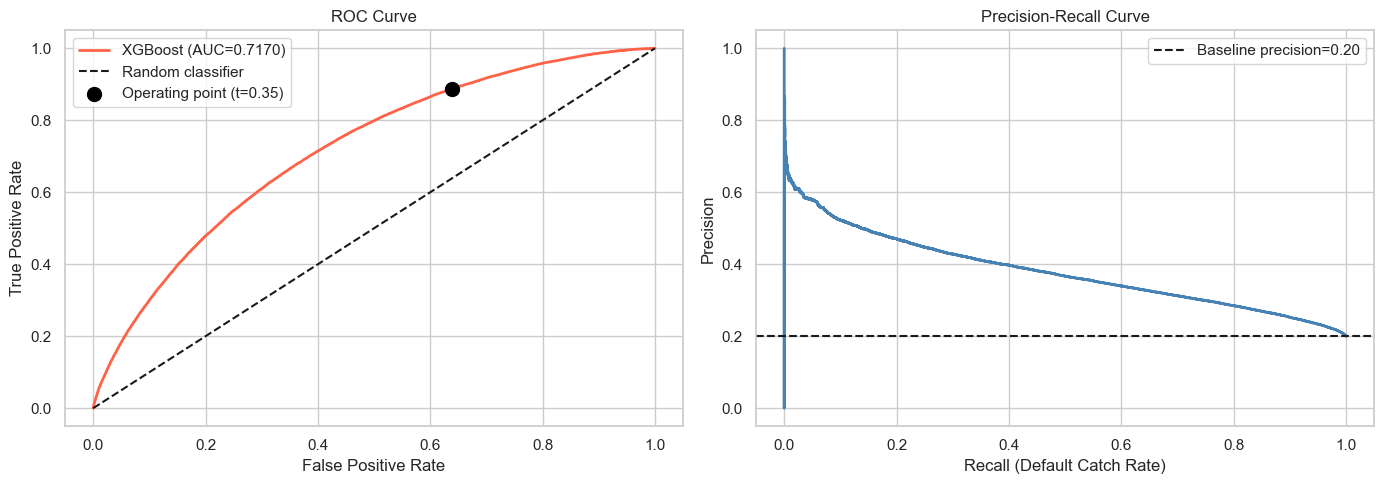

ROC-AUC: 0.7170


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
axes[0].plot(fpr, tpr, color='tomato', lw=2, label=f'XGBoost (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1],'k--', label='Random classifier')
axes[0].scatter(
    fp/(tn+fp), tp/(tp+fn),
    color='black', s=100, zorder=5,
    label=f'Operating point (t={THRESHOLD})'
)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall Curve
prec, rec, thresh_pr = precision_recall_curve(y_test, proba)
axes[1].plot(rec, prec, color='steelblue', lw=2)
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='k', linestyle='--', label=f'Baseline precision={baseline_pr:.2f}')
axes[1].set_xlabel('Recall (Default Catch Rate)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/eval_roc_pr.png', dpi=100)
plt.show()

print(f'ROC-AUC: {auc:.4f}')

## 3. Feature Importance

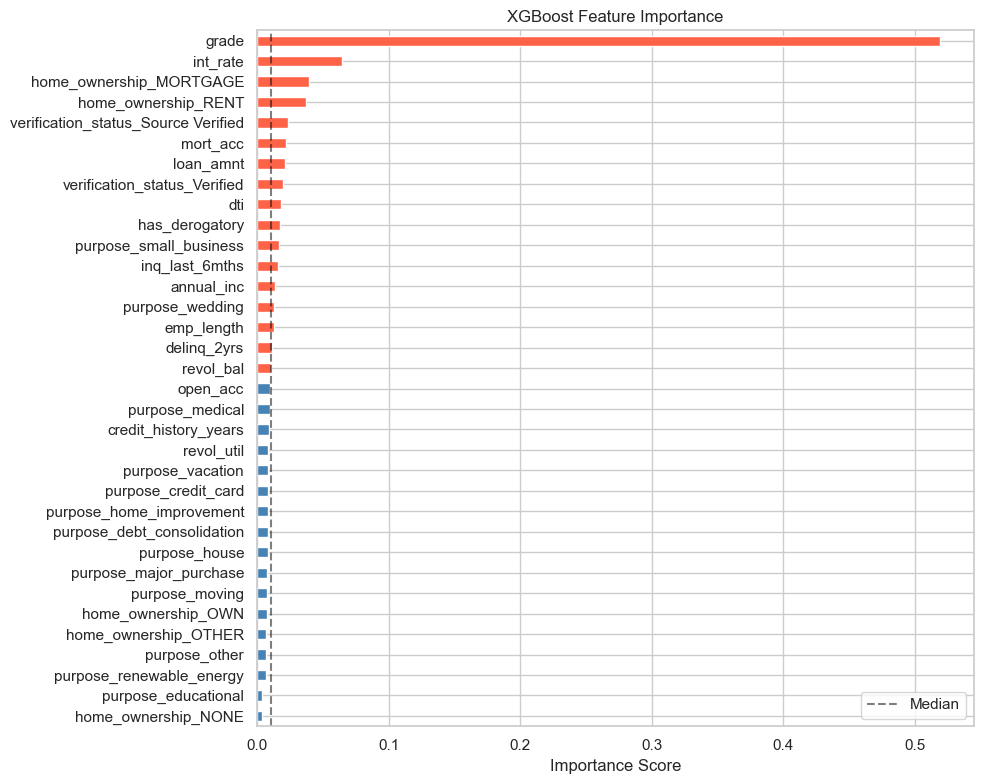

Top 10 features:
grade                                  0.5190
int_rate                               0.0642
home_ownership_MORTGAGE                0.0396
home_ownership_RENT                    0.0367
verification_status_Source Verified    0.0231
mort_acc                               0.0217
loan_amnt                              0.0214
verification_status_Verified           0.0192
dti                                    0.0181
has_derogatory                         0.0174
dtype: float32


In [4]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if v > feat_imp.median() else 'steelblue' for v in feat_imp_sorted]
feat_imp_sorted.plot(kind='barh', ax=ax, color=colors)
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance Score')
ax.axvline(feat_imp.median(), color='black', linestyle='--', alpha=0.5, label='Median')
ax.legend()
plt.tight_layout()
plt.savefig('../data/eval_feature_importance.png', dpi=100)
plt.show()

print('Top 10 features:')
print(feat_imp.sort_values(ascending=False).head(10).round(4))

## 4. Business Impact Summary

In [5]:
total = len(y_test)
approved = tn + fn
rejected = tp + fp
default_rate_no_model = (tp + fn) / total
default_rate_approved  = fn / approved if approved > 0 else 0
default_reduction = (default_rate_no_model - default_rate_approved) / default_rate_no_model
catch_rate = tp / (tp + fn)
good_rej_rate = fp / (tn + fp)

print('=' * 50)
print('       BUSINESS IMPACT SUMMARY')
print('=' * 50)
print(f'Total applications evaluated:  {total:>10,}')
print(f'Loans approved by model:       {approved:>10,}  ({approved/total:.1%})')
print(f'Loans rejected by model:       {rejected:>10,}  ({rejected/total:.1%})')
print()
print(f'--- Default Performance ---')
print(f'Defaults in test set:          {tp+fn:>10,}')
print(f'Defaults caught & rejected:    {tp:>10,}  ({catch_rate:.1%} catch rate)')
print(f'Defaults missed (approved):    {fn:>10,}')
print()
print(f'--- Default Rate Comparison ---')
print(f'Without model (all approved):  {default_rate_no_model:>10.2%}')
print(f'With model (approved only):    {default_rate_approved:>10.2%}')
print(f'Default rate reduction:        {default_reduction:>10.1%}')
print()
print(f'--- Good Borrower Impact ---')
print(f'Good borrowers in test set:    {tn+fp:>10,}')
print(f'Good borrowers approved:       {tn:>10,}  ({tn/(tn+fp):.1%})')
print(f'Good borrowers rejected (FP):  {fp:>10,}  ({good_rej_rate:.1%})')
print()
print(f'ROC-AUC:  {auc:.4f}')
print(f'F2 Score: {fbeta_score(y_test, preds, beta=2):.4f}')
print(f'Threshold used: {THRESHOLD}')
print('=' * 50)

       BUSINESS IMPACT SUMMARY
Total applications evaluated:     269,612
Loans approved by model:           83,834  (31.1%)
Loans rejected by model:          185,778  (68.9%)

--- Default Performance ---
Defaults in test set:              53,864
Defaults caught & rejected:        47,830  (88.8% catch rate)
Defaults missed (approved):         6,034

--- Default Rate Comparison ---
Without model (all approved):      19.98%
With model (approved only):         7.20%
Default rate reduction:             64.0%

--- Good Borrower Impact ---
Good borrowers in test set:       215,748
Good borrowers approved:           77,800  (36.1%)
Good borrowers rejected (FP):     137,948  (63.9%)

ROC-AUC:  0.7170
F2 Score: 0.5960
Threshold used: 0.35


## 5. Hypothesis Validation Summary

In [6]:
hypotheses = [
    ['H1', 'Higher DTI -> Higher Default',        'dti',                  19.75, 17.10, 'CONFIRMED',       'dti in top 5 features'],
    ['H2', 'Shorter Credit History -> Default',   'credit_history_years', 17.85, 18.68, 'WEAK',            'Only 0.83yr difference'],
    ['H3', 'Loan Purpose -> Higher Risk',         'purpose',              '-',   '-',   'CONFIRMED',       'Chi2=4182, p=0.0'],
    ['H4', 'Lower Income -> Higher Default',      'annual_inc',           60000, 65000, 'CONFIRMED',       '$5k median gap'],
    ['H5', 'More Derogatory Marks -> Default',    'has_derogatory',       0.246, 0.207, 'WEAK',            'Converted to binary flag'],
]

hyp_df = pd.DataFrame(
    hypotheses,
    columns=['ID', 'Hypothesis', 'Feature', 'Default Val', 'Paid Val', 'Verdict', 'Notes']
)
print(hyp_df.to_string(index=False))

# Feature importance for hypothesis features
hyp_features = ['dti', 'credit_history_years', 'annual_inc', 'has_derogatory']
print('\nFeature importance for hypothesis features:')
for f in hyp_features:
    if f in feat_imp.index:
        print(f'  {f:25s}: {feat_imp[f]:.4f}')

ID                        Hypothesis              Feature Default Val Paid Val   Verdict                    Notes
H1      Higher DTI -> Higher Default                  dti       19.75     17.1 CONFIRMED    dti in top 5 features
H2 Shorter Credit History -> Default credit_history_years       17.85    18.68      WEAK   Only 0.83yr difference
H3       Loan Purpose -> Higher Risk              purpose           -        - CONFIRMED         Chi2=4182, p=0.0
H4    Lower Income -> Higher Default           annual_inc       60000    65000 CONFIRMED           $5k median gap
H5  More Derogatory Marks -> Default       has_derogatory       0.246    0.207      WEAK Converted to binary flag

Feature importance for hypothesis features:
  dti                      : 0.0181
  credit_history_years     : 0.0092
  annual_inc               : 0.0137
  has_derogatory           : 0.0174


## 6. Score Distribution Plot

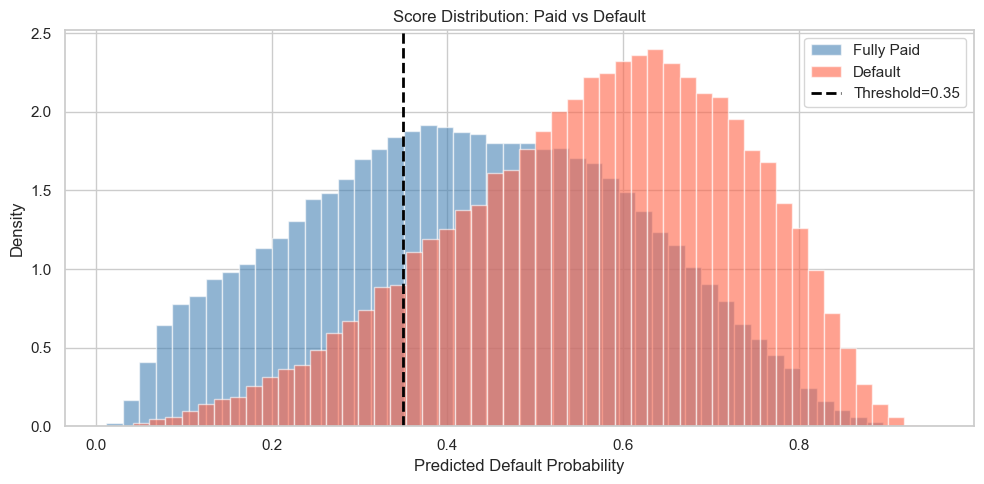

Median predicted probability:
  Fully Paid: 0.425
  Default:    0.568


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(proba[y_test==0], bins=50, alpha=0.6, color='steelblue', label='Fully Paid', density=True)
ax.hist(proba[y_test==1], bins=50, alpha=0.6, color='tomato',    label='Default',    density=True)
ax.axvline(THRESHOLD, color='black', linestyle='--', lw=2, label=f'Threshold={THRESHOLD}')
ax.set_xlabel('Predicted Default Probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution: Paid vs Default')
ax.legend()
plt.tight_layout()
plt.savefig('../data/eval_score_dist.png', dpi=100)
plt.show()

print('Median predicted probability:')
print(f'  Fully Paid: {proba[y_test==0].mean():.3f}')
print(f'  Default:    {proba[y_test==1].mean():.3f}')